# WiFi — Deduplicación y Análisis de Ocupación
## Campus UPF Poblenou · TFG Smart Campus

Transforma los logs crudos del WLC (24M conexiones WiFi) en métricas de ocupación real por persona, zona y hora.

| # | Bloque | Salida |
|---|--------|--------|
| 1 | Carga de datos | `df`, `df_gt` |
| 2 | Análisis inflación WiFi | Factor MAC/persona |
| 3 | Ocupación horaria global | `ocupacion_por_hora.csv` |
| 4 | Presencia por zona | `presence_user_hourly.parquet` |
| 5 | Features de movilidad | `user_daily_features.parquet` |
| 6 | Carga de APs | `ap_hourly_load.parquet` |
| 7 | Heatmaps por perfil | Figuras distribución |
| 8 | Visualizaciones campus | Mapas y series temporales |
| 9 | IMO (Mala Ocupación) | `imo_zona_hora.parquet` |
| 10 | Validaciones con GT | Métricas de calidad |

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS Y CONFIGURACIÓN GLOBAL
# ══════════════════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# ── Rutas ────────────────────────────────────────────────────────────────────
RAW_PATH = Path('../data/raw/Conexiones_WiFi_Campus.csv')
OUT_DIR  = Path('../data/interim')
OUTPUTS  = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

# ── Constantes de dominio ────────────────────────────────────────────────────
EQUIP    = 'equipament.poblenou@upf.edu'
PERFILES = ['GRADO', 'MASTER', 'PROFESOR', 'PAS', 'VISITANTE']
DIAS     = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

# Rango horario lectivo 
HORA_INICIO = 7
HORA_FIN    = 22
MIN_ALUMNOS = 20  # umbral mínimo para horas con datos suficientes

print('✅ Configuración cargada')

✅ Configuración cargada


---
## Bloque 1 — Carga de datos crudos

Lee el CSV del WLC y separa las columnas de _ground truth_ (GT_*) del pipeline de features,
de modo que el modelo de deduplicación nunca vea las etiquetas reales.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 1 — Cargar CSV crudo
# ─────────────────────────────────────────────────────────────────────────────
print('Cargando CSV crudo...')
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'], format='%d/%m/%Y %H:%M')

# Firewall: separar features de ground truth
gt_cols = [c for c in df_raw.columns if c.startswith('GT_')]
df      = df_raw.drop(columns=gt_cols)             # ← lo único que ve el pipeline
df_gt   = df_raw[['SessionID', 'Username'] + gt_cols]  # ← solo para validación

print(f'Total filas crudas:      {len(df):,}')
print(f'Columnas features:       {df.columns.tolist()}')
print(f'Columnas GT (aisladas):  {gt_cols}')

Cargando CSV crudo...
Total filas crudas:      23,684,390
Columnas features:       ['Timestamp', 'SessionID', 'Username', 'MAC_Address', 'AP_Name', 'AP_Zone', 'RSSI_dBm', 'SNR_dB']
Columnas GT (aisladas):  ['GT_TipoAgente', 'GT_ZonaDestino', 'GT_Distance_m', 'GT_X', 'GT_Y']


---
## Bloque 2 — Análisis de inflación WiFi

Compara cuatro métricas de "ocupación" sobre una semana tipo para cuantificar
cuánto sobreestima el contador WLC ingenuo (MACs únicas) respecto a personas reales (Username único).

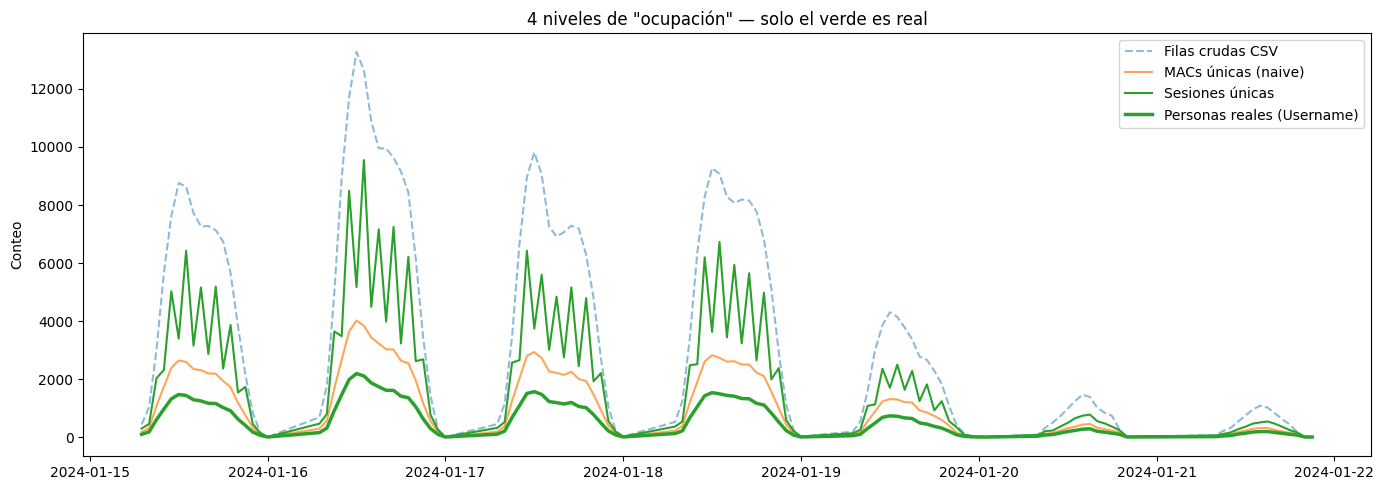


Factor de inflación MAC/persona: 1.84×
Si el responsable energético contara MACs, sobrestimaría ocupación 84%


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 2 — Inflación WiFi: 4 niveles de conteo
# ─────────────────────────────────────────────────────────────────────────────

mask = (df['Timestamp'] >= '2024-01-15') & (df['Timestamp'] < '2024-01-22')
df_w = df[mask].copy()
df_w['Hour'] = df_w['Timestamp'].dt.ceil('1h')

df_w_p = df_w[df_w['Username'] != EQUIP]

resumen = df_w_p.groupby('Hour').agg(
    filas_csv   =('Timestamp',   'count'),
    macs_unicas =('MAC_Address', 'nunique'),
    sesiones    =('SessionID',   'nunique'),
    personas    =('Username',    'nunique'),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(resumen['Hour'], resumen['filas_csv'],   label='Filas crudas CSV',       alpha=0.5, ls='--')
ax.plot(resumen['Hour'], resumen['macs_unicas'], label='MACs únicas (naive)',     alpha=0.7)
ax.plot(resumen['Hour'], resumen['sesiones'],    label='Sesiones únicas')
ax.plot(resumen['Hour'], resumen['personas'],    label='Personas reales (Username)', lw=2.5, color='C2')
ax.set_title('4 niveles de "ocupación" — solo el verde es real')
ax.set_ylabel('Conteo')
ax.legend()
plt.tight_layout()
plt.show()

ratio = resumen['macs_unicas'].sum() / resumen['personas'].sum()
print(f'\nFactor de inflación MAC/persona: {ratio:.2f}×')
print(f'Si el responsable energético contara MACs, sobrestimaría ocupación {(ratio-1)*100:.0f}%')

---
## Bloque 3 — Ocupación horaria global

Agrega el número de personas únicas (Username) por hora, forzando continuidad
desde el primer día con ceros en horas sin datos.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 3 — Ocupación horaria global con continuidad
# ─────────────────────────────────────────────────────────────────────────────
# Right-labeling: ceil() → la hora 09:00 representa el período 08:00–09:00
# Coincide con la lógica del sistema Java del WLC
df['Hour'] = df['Timestamp'].dt.ceil('1h')

usuarios_por_hora = (
    df[df['Username'] != EQUIP]
    .groupby('Hour')['Username']
    .nunique()
    .reset_index(name='usuarios_unicos')
)

# Forzar continuidad: rellenar horas sin datos con 0
fecha_inicio  = usuarios_por_hora['Hour'].min().floor('D')  # desde las 00:00 del primer día
fecha_fin     = usuarios_por_hora['Hour'].max()
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='h')

ocupacion_horaria = (
    usuarios_por_hora
    .set_index('Hour')
    .reindex(rango_completo)
    .fillna(0)
    .reset_index()
)
ocupacion_horaria.columns = ['Timestamp', 'personas_total']
ocupacion_horaria['personas_total'] = ocupacion_horaria['personas_total'].astype(int)

ocupacion_horaria.to_csv(OUT_DIR / 'ocupacion_por_hora.csv', index=False)

print(f'Inicio forzado: {fecha_inicio}')
print(ocupacion_horaria.head(10))
print('\nVerificación — horas nocturnas (debería haber ceros):')
print(ocupacion_horaria.set_index('Timestamp').between_time('02:00', '05:00').head())
print(f'\n✅ Guardado: {len(ocupacion_horaria):,} filas (incluyendo horas con 0)')

Inicio forzado: 2024-01-01 00:00:00
            Timestamp  personas_total
0 2024-01-01 00:00:00               0
1 2024-01-01 01:00:00               0
2 2024-01-01 02:00:00               0
3 2024-01-01 03:00:00               0
4 2024-01-01 04:00:00               0
5 2024-01-01 05:00:00               0
6 2024-01-01 06:00:00               0
7 2024-01-01 07:00:00               0
8 2024-01-01 08:00:00              18
9 2024-01-01 09:00:00              66

Verificación — horas nocturnas (debería haber ceros):
                     personas_total
Timestamp                          
2024-01-01 02:00:00               0
2024-01-01 03:00:00               0
2024-01-01 04:00:00               0
2024-01-01 05:00:00               0
2024-01-02 02:00:00               0

✅ Guardado: 8,781 filas (incluyendo horas con 0)


---
## Bloque 4 — Presencia por zona (zona dominante por hora)

Para cada usuario y hora, determina en qué zona estuvo la mayor parte del tiempo
(por número de muestras WiFi). Se filtra el equipamiento fijo para no distorsionar los conteos.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 4 — Presencia por zona: zona dominante por (Usuario, Hora)
# ─────────────────────────────────────────────────────────────────────────────
df['Hour'] = df['Timestamp'].dt.ceil('1h')

mask_equip  = df['Username'] == EQUIP
df_personas = df[~mask_equip].copy()
df_fijos    = df[ mask_equip].copy()

# Zona dominante: la que acumula más muestras en esa hora
zona_dominante = (
    df_personas
    .groupby(['Username', 'Hour', 'AP_Zone'])
    .size()
    .reset_index(name='samples')
    .sort_values(['Username', 'Hour', 'samples'], ascending=[True, True, False])
    .drop_duplicates(['Username', 'Hour'])
    .drop(columns='samples')
)

presence = zona_dominante.rename(columns={'AP_Zone': 'Zone'})
presence['Date']    = presence['Hour'].dt.date
presence['HourInt'] = presence['Hour'].dt.hour
presence['DOW']     = presence['Hour'].dt.dayofweek  # 0=Lun

presence.to_parquet(OUT_DIR / 'presence_user_hourly.parquet')
print(f'✅ Guardado: presence_user_hourly.parquet ({len(presence):,} filas)')
print(presence.head())

✅ Guardado: presence_user_hourly.parquet (3,431,969 filas)
            Username                Hour         Zone        Date  HourInt  \
0  ID_100000@upf.edu 2024-02-06 15:00:00    Cafeteria  2024-02-06       15   
2  ID_100000@upf.edu 2024-02-06 16:00:00    Cafeteria  2024-02-06       16   
3  ID_100000@upf.edu 2024-02-06 17:00:00  AreaTallers  2024-02-06       17   
4  ID_100001@upf.edu 2024-02-06 15:00:00  AreaTallers  2024-02-06       15   
6  ID_100001@upf.edu 2024-02-06 16:00:00  AreaTallers  2024-02-06       16   

   DOW  
0    1  
2    1  
3    1  
4    1  
6    1  


---
## Bloque 5 — Features de movilidad por usuario-día

Genera un vector de características por `(Username, Date)` que captura el comportamiento
de movilidad: sesiones, zonas visitadas, tiempo en campus, ratio de movilidad, etc.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 5 — Features de movilidad: una fila por (Usuario, Día)
# ─────────────────────────────────────────────────────────────────────────────
features = (
    df_personas
    .groupby([df_personas['Username'], df_personas['Hour'].dt.date])
    .agg(
        n_sesiones        =('SessionID',   'nunique'),
        n_aps_distintos   =('AP_Name',     'nunique'),
        n_zonas_distintas =('AP_Zone',     'nunique'),
        n_dispositivos    =('MAC_Address', 'nunique'),
        primera_hora      =('Timestamp',   'min'),
        ultima_hora       =('Timestamp',   'max'),
        rssi_medio        =('RSSI_dBm',    'mean'),
        snr_medio         =('SNR_dB',      'mean'),
    )
    .reset_index()
    .rename(columns={'Hour': 'Date'})
)

# Features derivadas
features['minutos_campus'] = (
    (features['ultima_hora'] - features['primera_hora']).dt.total_seconds() / 60
).clip(lower=15)  # mínimo 15 min (un escaneo)

features['dwell_por_sesion'] = features['minutos_campus'] / features['n_sesiones']
features['ratio_movilidad']  = features['n_aps_distintos'] / features['n_sesiones']

hora_centro = (
    df_personas
    .groupby([df_personas['Username'], df_personas['Hour'].dt.date])['Hour']
    .agg(lambda x: x.dt.hour.median())
    .reset_index(name='hora_centro')
)
hora_centro.columns = ['Username', 'Date', 'hora_centro']
features = features.merge(hora_centro, on=['Username', 'Date'], how='left')

features.to_parquet(OUT_DIR / 'user_daily_features.parquet')
print(f'✅ Guardado: user_daily_features.parquet ({len(features):,} filas)')
print(features.head())

✅ Guardado: user_daily_features.parquet (846,474 filas)
            Username        Date  n_sesiones  n_aps_distintos  \
0  ID_100000@upf.edu  2024-02-06           3                3   
1  ID_100001@upf.edu  2024-02-06          16                7   
2  ID_100002@upf.edu  2024-02-06          12                4   
3  ID_100003@upf.edu  2024-02-06          21                7   
4  ID_100004@upf.edu  2024-02-06           2                1   

   n_zonas_distintas  n_dispositivos        primera_hora         ultima_hora  \
0                  3               1 2024-02-06 14:30:00 2024-02-06 16:15:00   
1                  5               2 2024-02-06 14:30:00 2024-02-06 20:15:00   
2                  2               2 2024-02-06 14:30:00 2024-02-06 18:30:00   
3                  5               3 2024-02-06 14:30:00 2024-02-06 19:45:00   
4                  1               2 2024-02-06 14:30:00 2024-02-06 14:30:00   

   rssi_medio  snr_medio  minutos_campus  dwell_por_sesion  ratio_movili

---
## Bloque 6 — Carga horaria de puntos de acceso (AP)

Agrega las conexiones por `(Hora, AP_Name, AP_Zone)` para analizar la carga
de cada punto de acceso y detectar zonas saturadas o infrautilizadas.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 6 — Carga horaria por AP y zona
# ─────────────────────────────────────────────────────────────────────────────
ap_load = (
    df
    .groupby([df['Hour'], 'AP_Name', 'AP_Zone'])
    .agg(
        conexiones_totales  =('Timestamp',   'count'),
        dispositivos_unicos =('MAC_Address', 'nunique'),
        sesiones_unicas     =('SessionID',   'nunique'),
        personas_unicas     =('Username',    lambda x: x[x != EQUIP].nunique()),
        rssi_medio          =('RSSI_dBm',    'mean'),
    )
    .reset_index()
)

ap_load.to_parquet(OUT_DIR / 'ap_hourly_load.parquet')
print(f'✅ Guardado: ap_hourly_load.parquet ({len(ap_load):,} filas)')

✅ Guardado: ap_hourly_load.parquet (210,159 filas)


In [8]:
print(ap_load.head())

                 Hour   AP_Name       AP_Zone  conexiones_totales  \
0 2024-01-01 01:00:00  AP_50_03     LaFabrica                  36   
1 2024-01-01 01:00:00  AP_50_04     LaFabrica                  76   
2 2024-01-01 01:00:00  AP_50_05     LaFabrica                  28   
3 2024-01-01 01:00:00  AP_51_03         LaNau                   4   
4 2024-01-01 01:00:00  AP_52_01  RocBoronat52                   8   

   dispositivos_unicos  sesiones_unicas  personas_unicas  rssi_medio  
0                    9                9                0  -65.277778  
1                   19               19                0  -61.300000  
2                    7                7                0  -64.285714  
3                    1                1                0  -40.200000  
4                    2                2                0  -66.450000  


---
## Bloque 7 — Heatmaps por perfil de usuario

Usa el _ground truth_ para visualizar cómo se distribuye cada perfil (GRADO, MASTER, etc.)
por zonas del campus y por hora del día.

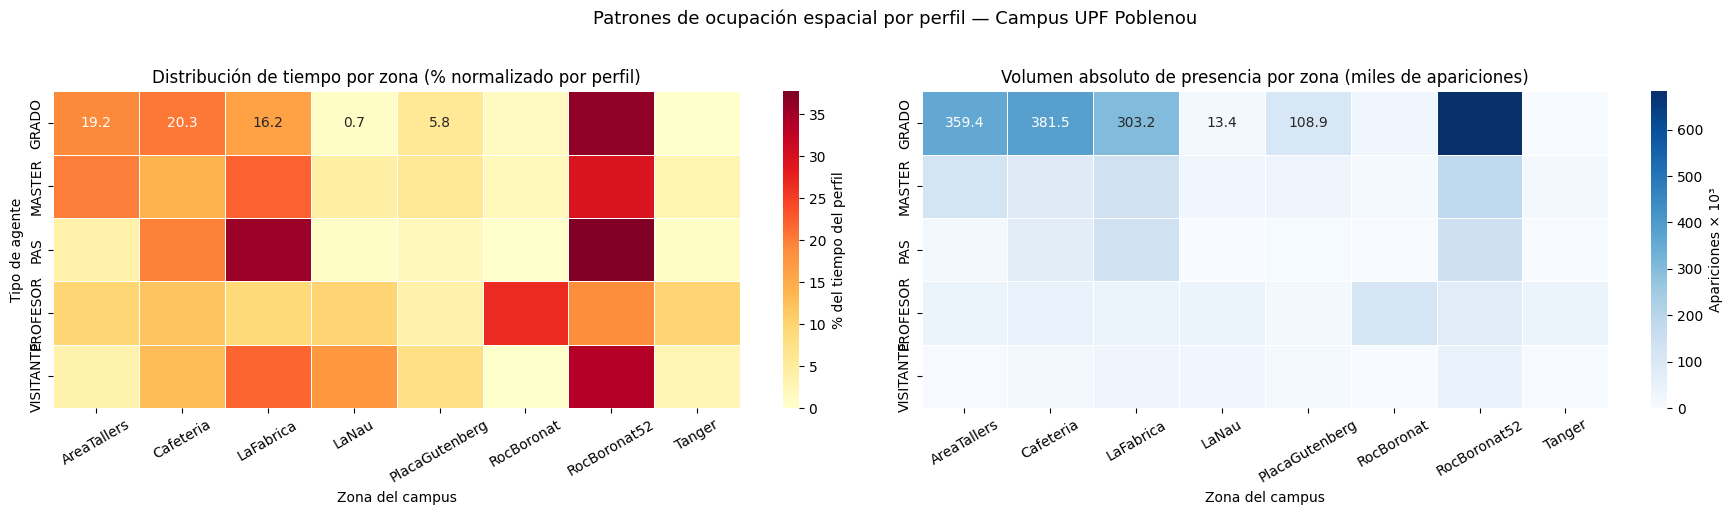

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 7 — Heatmap zona × perfil
# ─────────────────────────────────────────────────────────────────────────────
# Unir presencia con tipo de agente (GT solo para validación/viz)
presence_gt = presence.merge(
    df_gt[['Username', 'GT_TipoAgente']].drop_duplicates(subset='Username'),
    on='Username', how='left'
).dropna(subset=['GT_TipoAgente'])

presence_gt = presence_gt[presence_gt['GT_TipoAgente'] != 'FIJO']

# Pivot: (TipoAgente × Zona) = nº de apariciones horarias
pivot = (
    presence_gt
    .groupby(['GT_TipoAgente', 'Zone'])
    .size()
    .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% del tiempo del perfil'}, ax=axes[0])
axes[0].set_title('Distribución de tiempo por zona (% normalizado por perfil)', fontsize=12)
axes[0].set_xlabel('Zona del campus'); axes[0].set_ylabel('Tipo de agente')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pivot / 1000, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Apariciones × 10³'}, ax=axes[1])
axes[1].set_title('Volumen absoluto de presencia por zona (miles de apariciones)', fontsize=12)
axes[1].set_xlabel('Zona del campus'); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Patrones de ocupación espacial por perfil — Campus UPF Poblenou',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'heatmap_zonas_por_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

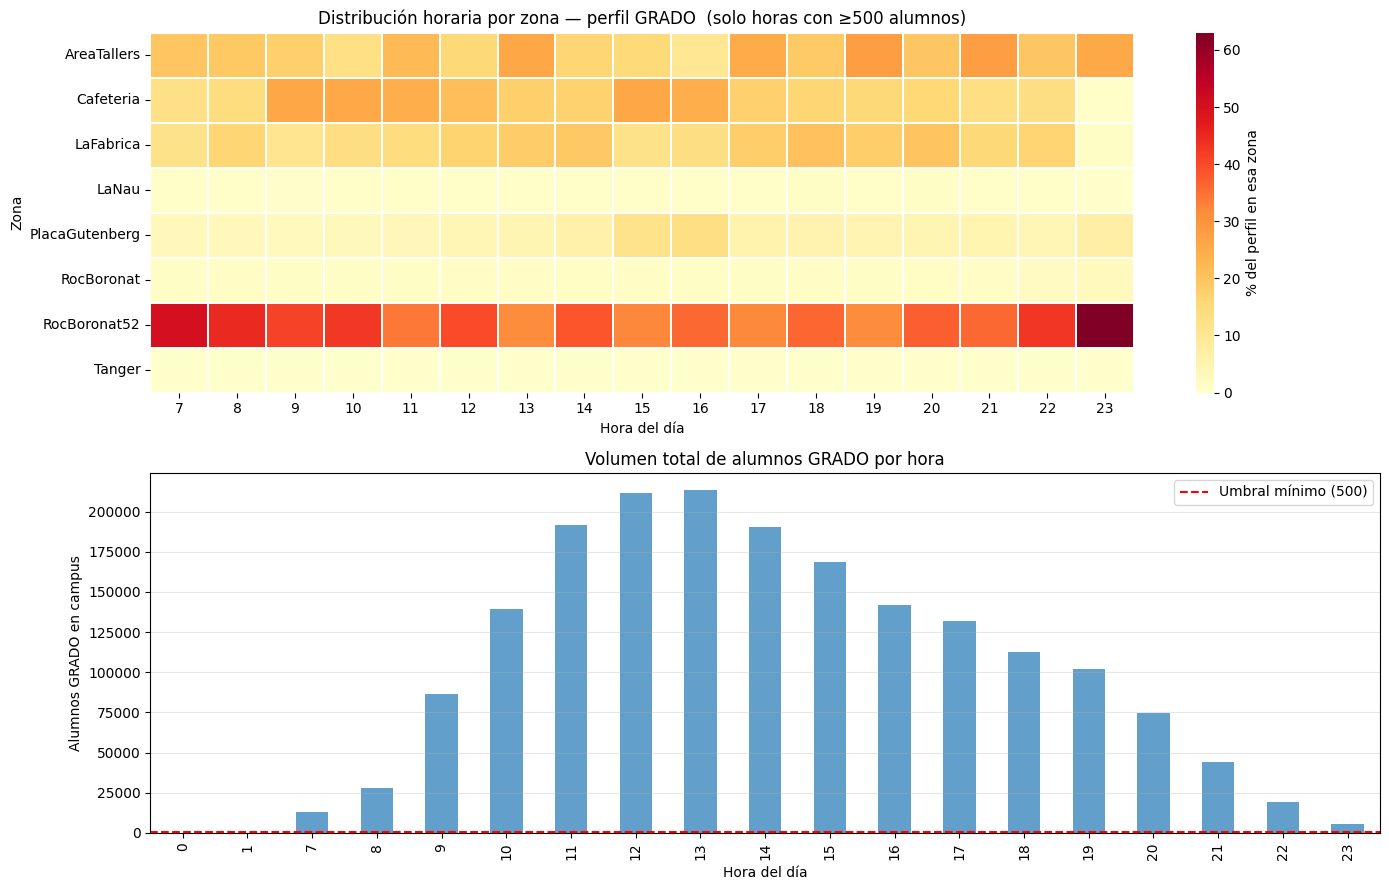

Horas excluidas por bajo volumen: [0, 1, 2, 3, 4, 5, 6]
Alumnos a las 23h: 5668
Alumnos a las 12h: 211773


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 7b — Heatmap horario para perfil GRADO
# ─────────────────────────────────────────────────────────────────────────────
perfil = 'GRADO'

pivot_hora = (
    presence_gt[presence_gt['GT_TipoAgente'] == perfil]
    .groupby(['HourInt', 'Zone'])
    .size()
    .unstack(fill_value=0)
)
MIN_ALUMNOS = 500
# Filtrar horas con volumen insuficiente para evitar distorsión porcentual
total_por_hora  = pivot_hora.sum(axis=1)
horas_validas   = total_por_hora[total_por_hora >= MIN_ALUMNOS].index
pivot_hora_fil  = pivot_hora.loc[horas_validas]
pivot_hora_pct  = pivot_hora_fil.div(pivot_hora_fil.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.heatmap(pivot_hora_pct.T, annot=False, cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': '% del perfil en esa zona'}, ax=axes[0])
axes[0].set_title(f'Distribución horaria por zona — perfil {perfil}  '
                   f'(solo horas con ≥{MIN_ALUMNOS} alumnos)')
axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('Zona')

total_por_hora.plot(kind='bar', ax=axes[1], color='C0', alpha=0.7)
axes[1].axhline(MIN_ALUMNOS, color='red', ls='--',
                 label=f'Umbral mínimo ({MIN_ALUMNOS})')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel(f'Alumnos {perfil} en campus')
axes[1].set_title(f'Volumen total de alumnos {perfil} por hora')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUTS / f'heatmap_horario_{perfil}_corregido.png', dpi=150, bbox_inches='tight')
plt.show()

horas_excluidas = sorted(set(range(24)) - set(horas_validas.tolist()))
print(f'Horas excluidas por bajo volumen: {horas_excluidas}')
# [FIX] Corregido bug: segundo print decía "23h" pero era la hora 12
print(f'Alumnos a las 23h: {int(total_por_hora.get(23, 0))}')
print(f'Alumnos a las 12h: {int(total_por_hora.get(12, 0))}')

---
## Bloque 8 — Setup de visualizaciones del campus

Prepara las estructuras necesarias para las visualizaciones espaciales:
- `occ_zona`: ocupación agregada por hora y zona
- `norm_zone()`: normalización de nombres de zona
- `EDIFICIOS`: coordenadas de cada edificio en espacio 0-100
- `dibujar_campus()`: función para mapas choropleth del campus

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 8 — Setup: ocupación por zona + utilidades de visualización
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Ocupación horaria por zona (desde presence ya calculado en Bloque 4)
occ_zona = (
    presence
    .groupby(['Hour', 'Zone'])['Username']
    .nunique()
    .reset_index(name='personas')
)
occ_zona['hora']    = occ_zona['Hour'].dt.hour
occ_zona['dia_sem'] = occ_zona['Hour'].dt.dayofweek
occ_zona['lectivo'] = occ_zona['dia_sem'] < 5

# Normalización de nombres de zona (definida UNA SOLA VEZ aquí)
def norm_zone(z):
    m = {
        'lafabrica':      'LaFabrica',
        'la fabrica':     'LaFabrica',
        'lanau':          'LaNau',
        'la nau':         'LaNau',
        'rocboronat52':   'RocBoronat52',
        'roc b. baix':    'RocBoronat52',
        'rocboronat53':   'RocBoronat',
        'roc b. torre':   'RocBoronat',
        'areatallers':    'AreaTallers',
        'areatallers':    'AreaTallers',
        'placagutenberg': 'PlacaGutenberg',
        'cafeteria':      'Cafeteria',
    }
    key = (str(z).lower()
           .replace(' ', '').replace('á', 'a')
           .replace('à', 'a').replace('è', 'e').replace('ó', 'o'))
    return m.get(key, z)

occ_zona['ZoneKey'] = occ_zona['Zone'].apply(norm_zone)

# Coordenadas de edificios en espacio 0-100 del simulador
EDIFICIOS = {
    'LaFabrica':      {'x1': 70, 'x2': 95, 'y1': 15, 'y2': 70},
    'LaNau':          {'x1': 10, 'x2': 95, 'y1':  6, 'y2': 18},
    'RocBoronat52':   {'x1':  5, 'x2': 30, 'y1': 15, 'y2': 70},
    'RocBoronat':     {'x1':  5, 'x2': 20, 'y1': 75, 'y2':100},
    'AreaTallers':    {'x1': 35, 'x2': 95, 'y1': 70, 'y2':100},
    'Tanger':         {'x1': 15, 'x2': 85, 'y1':  0, 'y2':  8},
    'PlacaGutenberg': {'x1': 30, 'x2': 65, 'y1': 25, 'y2': 65},
    'Cafeteria':      {'x1':  5, 'x2': 30, 'y1': 15, 'y2': 35},
}

def dibujar_campus(ax, valores, titulo, cmap_name='YlOrRd',
                   vmin=0, vmax=None, label_cbar=''):
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_facecolor('#E8EDE8'); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titulo, fontsize=10, pad=6)
    if vmax is None:
        vals = [v for v in valores.values() if pd.notna(v) and v > 0]
        vmax = max(vals) if vals else 1
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    for key, info in EDIFICIOS.items():
        w  = info['x2'] - info['x1']
        h  = info['y2'] - info['y1']
        cx = (info['x1'] + info['x2']) / 2
        cy = (info['y1'] + info['y2']) / 2
        color = cmap(norm(valores.get(key, 0)))
        rect  = FancyBboxPatch((info['x1'], info['y1']), w, h,
                                boxstyle='round,pad=0.5', lw=1.5,
                                edgecolor='white', facecolor=color, alpha=0.88)
        ax.add_patch(rect)
        ax.text(cx, cy, key, ha='center', va='center',
            fontsize=6.5, fontweight='bold', color='white')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02).set_label(label_cbar, fontsize=8)

print('✅ Setup de visualizaciones listo')

✅ Setup de visualizaciones listo


---
### G1 — Heatmap Hora × Día de la semana

1/5 Heatmap hora × día de la semana...


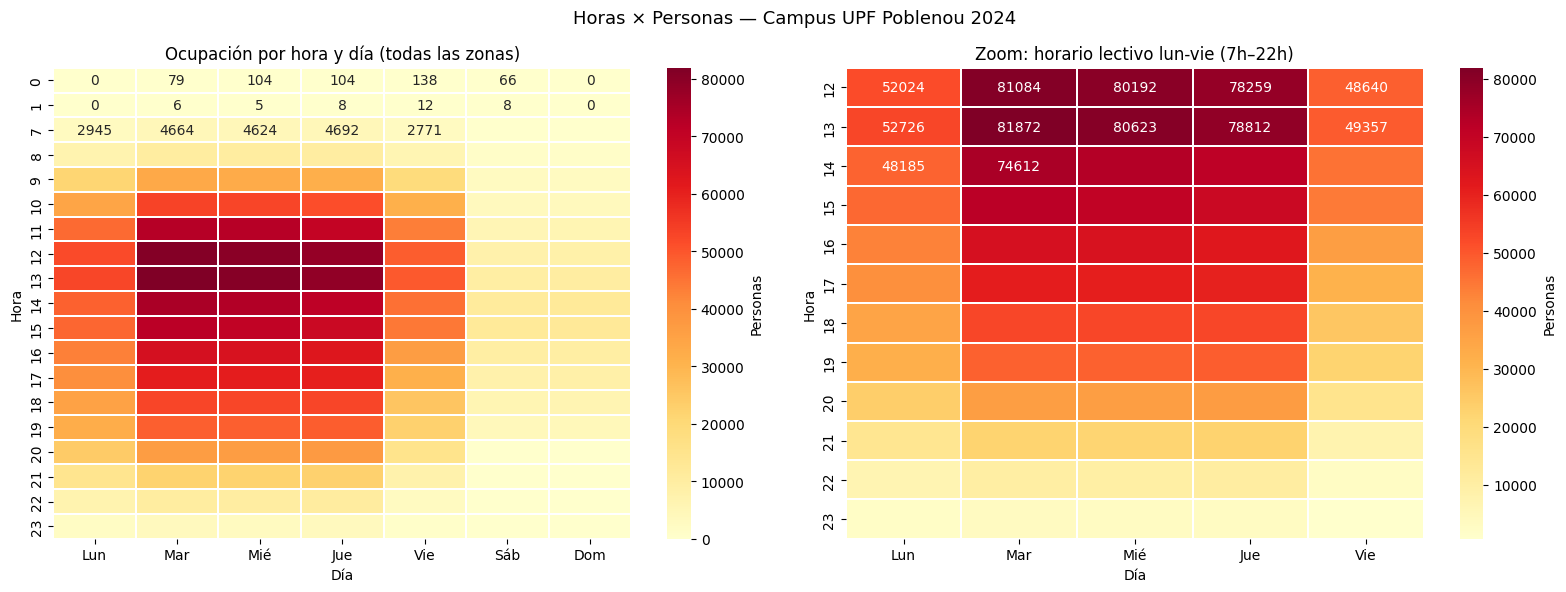

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 1 — Heatmap Hora × Día de la semana
# ─────────────────────────────────────────────────────────────────────────────
print('1/5 Heatmap hora × día de la semana...')

h_dow = occ_zona.groupby(['hora', 'dia_sem'])['personas'].sum().unstack(fill_value=0)
h_dow.columns = DIAS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(h_dow, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, cbar_kws={'label': 'Personas'}, ax=axes[0])
axes[0].set_title('Ocupación por hora y día (todas las zonas)')
axes[0].set_xlabel('Día'); axes[0].set_ylabel('Hora')

sns.heatmap(h_dow.iloc[7:22, :5], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, cbar_kws={'label': 'Personas'}, ax=axes[1])
axes[1].set_title(f'Zoom: horario lectivo lun-vie ({HORA_INICIO}h–{HORA_FIN}h)')
axes[1].set_xlabel('Día'); axes[1].set_ylabel('Hora')

plt.suptitle('Horas × Personas — Campus UPF Poblenou 2024', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'horas_personas_diasemana.png', dpi=150, bbox_inches='tight')
plt.show()

---
### G2 — Personas vs Conexiones WiFi (factor de inflación)

2/5 Personas vs WiFi connections...


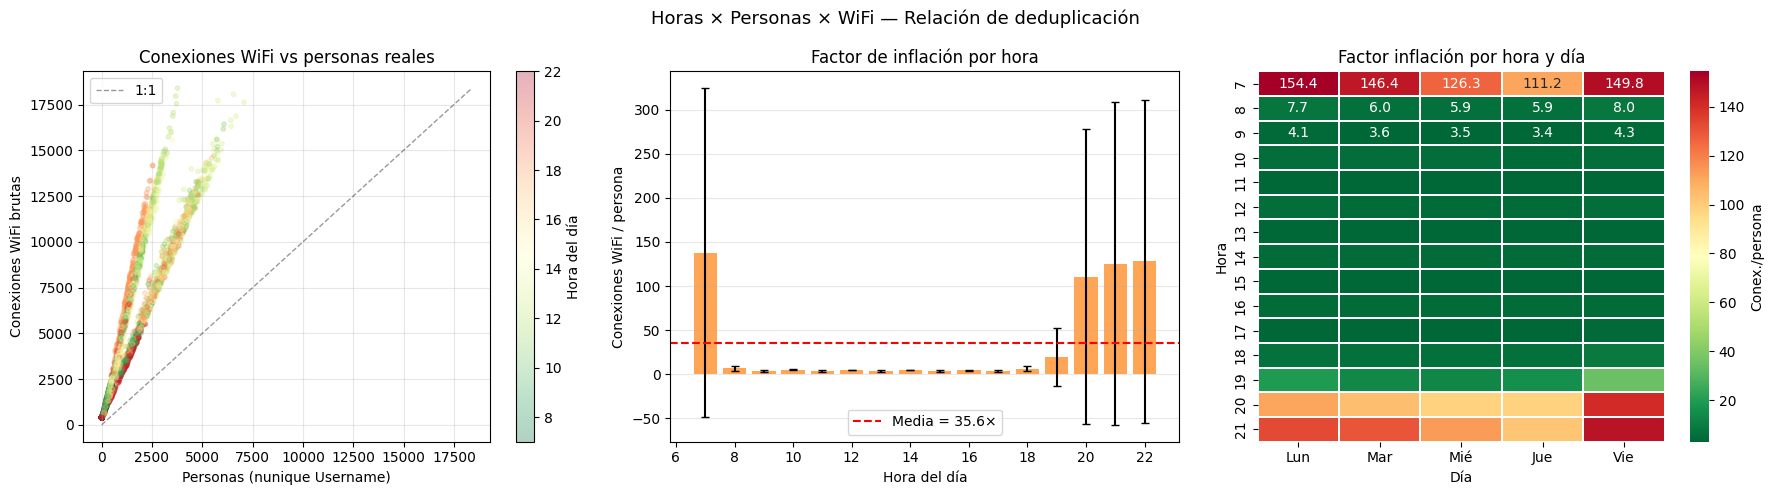

  Factor inflación medio: 35.60×


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 2 — Personas vs WiFi connections (triple panel)
# ─────────────────────────────────────────────────────────────────────────────
print('2/5 Personas vs WiFi connections...')

conn_h = (
    ap_load.copy()
    .assign(Hour=lambda d: pd.to_datetime(d['Hour']))
    .groupby('Hour')
    .agg(conexiones=('conexiones_totales', 'sum'),
         personas  =('personas_unicas',    'sum'))
    .reset_index()
)
conn_h['hora']    = conn_h['Hour'].dt.hour
conn_h['dia_sem'] = conn_h['Hour'].dt.dayofweek
conn_h['ratio']   = conn_h['conexiones'] / conn_h['personas'].clip(lower=1)

df_lect_c = conn_h[conn_h['dia_sem'].lt(5) & conn_h['hora'].between(HORA_INICIO, HORA_FIN)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter personas vs conexiones
sc = axes[0].scatter(df_lect_c['personas'], df_lect_c['conexiones'],
                      c=df_lect_c['hora'], cmap='RdYlGn_r', alpha=0.3, s=10)
lim = max(df_lect_c['personas'].max(), df_lect_c['conexiones'].max())
axes[0].plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.4, label='1:1')
plt.colorbar(sc, ax=axes[0], label='Hora del día')
axes[0].set_xlabel('Personas (nunique Username)')
axes[0].set_ylabel('Conexiones WiFi brutas')
axes[0].set_title('Conexiones WiFi vs personas reales')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Factor de inflación por hora
ratio_h = df_lect_c.groupby('hora')['ratio'].agg(['mean', 'std'])
axes[1].bar(ratio_h.index, ratio_h['mean'], yerr=ratio_h['std'],
            alpha=0.7, color='C1', capsize=3)
axes[1].axhline(ratio_h['mean'].mean(), color='red', ls='--',
                 label=f'Media = {ratio_h["mean"].mean():.1f}×')
axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel('Conexiones WiFi / persona')
axes[1].set_title('Factor de inflación por hora')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

# Heatmap del factor por hora y día
ratio_pivot = conn_h.groupby(['hora', 'dia_sem'])['ratio'].mean().unstack(fill_value=np.nan)
ratio_pivot.columns = DIAS
sns.heatmap(ratio_pivot.iloc[7:22, :5], cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.3, cbar_kws={'label': 'Conex./persona'}, ax=axes[2])
axes[2].set_title('Factor inflación por hora y día')
axes[2].set_xlabel('Día'); axes[2].set_ylabel('Hora')

plt.suptitle('Horas × Personas × WiFi — Relación de deduplicación', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'horas_personas_wifi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Factor inflación medio: {df_lect_c["ratio"].mean():.2f}×')

---
### G3 — Serie temporal semanal (doble eje)

3/5 Serie temporal semana...


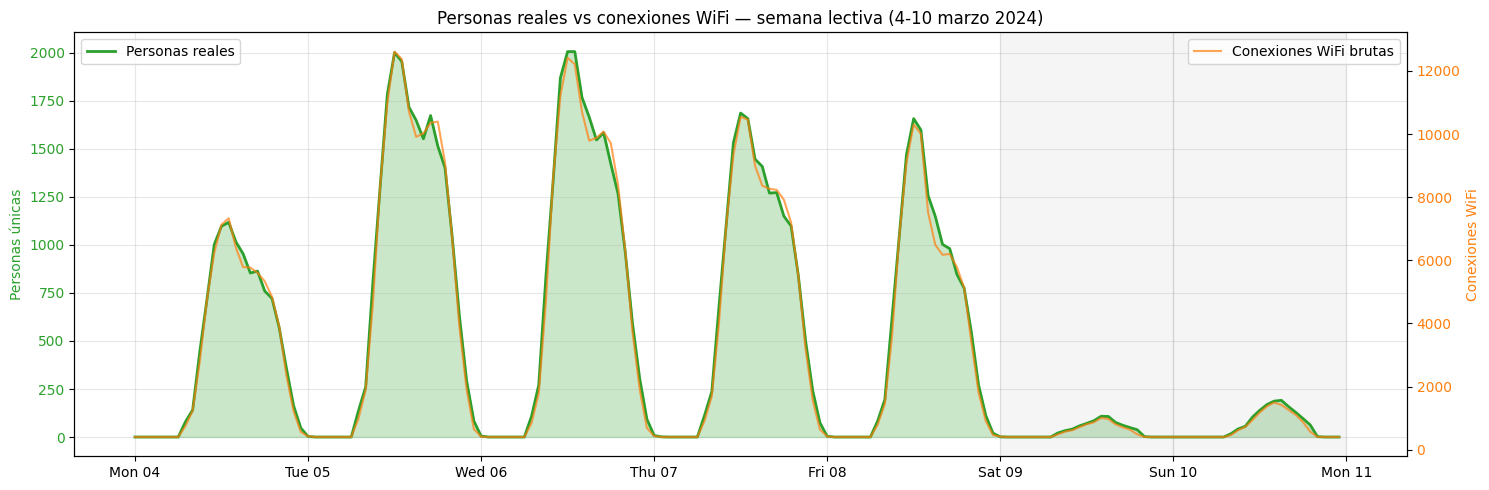

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 3 — Serie temporal semana (doble eje: personas vs conexiones)
# ─────────────────────────────────────────────────────────────────────────────
print('3/5 Serie temporal semana...')

occ_h = ocupacion_horaria.rename(columns={'Timestamp': 'Hour', 'personas_total': 'personas'}).copy()
occ_h['Hour'] = pd.to_datetime(occ_h['Hour'])

mw1   = (occ_h['Hour']   >= '2024-03-04') & (occ_h['Hour']   < '2024-03-11')
mw2   = (conn_h['Hour']  >= '2024-03-04') & (conn_h['Hour']  < '2024-03-11')
sem_p = occ_h[mw1]
sem_w = conn_h[mw2]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.fill_between(sem_p['Hour'], sem_p['personas'], alpha=0.25, color='C2')
ax1.plot(sem_p['Hour'], sem_p['personas'], lw=2, color='C2', label='Personas reales')
ax1.set_ylabel('Personas únicas', color='C2')
ax1.tick_params(axis='y', labelcolor='C2')

ax2 = ax1.twinx()
ax2.plot(sem_w['Hour'], sem_w['conexiones'], lw=1.5, color='C1', alpha=0.7,
          label='Conexiones WiFi brutas')
ax2.set_ylabel('Conexiones WiFi', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.legend(loc='upper right')

# Sombrear fines de semana
for d in pd.date_range('2024-03-04', '2024-03-11', freq='D'):
    if d.dayofweek >= 5:
        ax1.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08, color='gray')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.set_title('Personas reales vs conexiones WiFi — semana lectiva (4-10 marzo 2024)')
ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'serie_personas_wifi_semana.png', dpi=150, bbox_inches='tight')
plt.show()

---
### G4 — Mapa choropleth del campus

4/5 Mapa campus — ocupación...


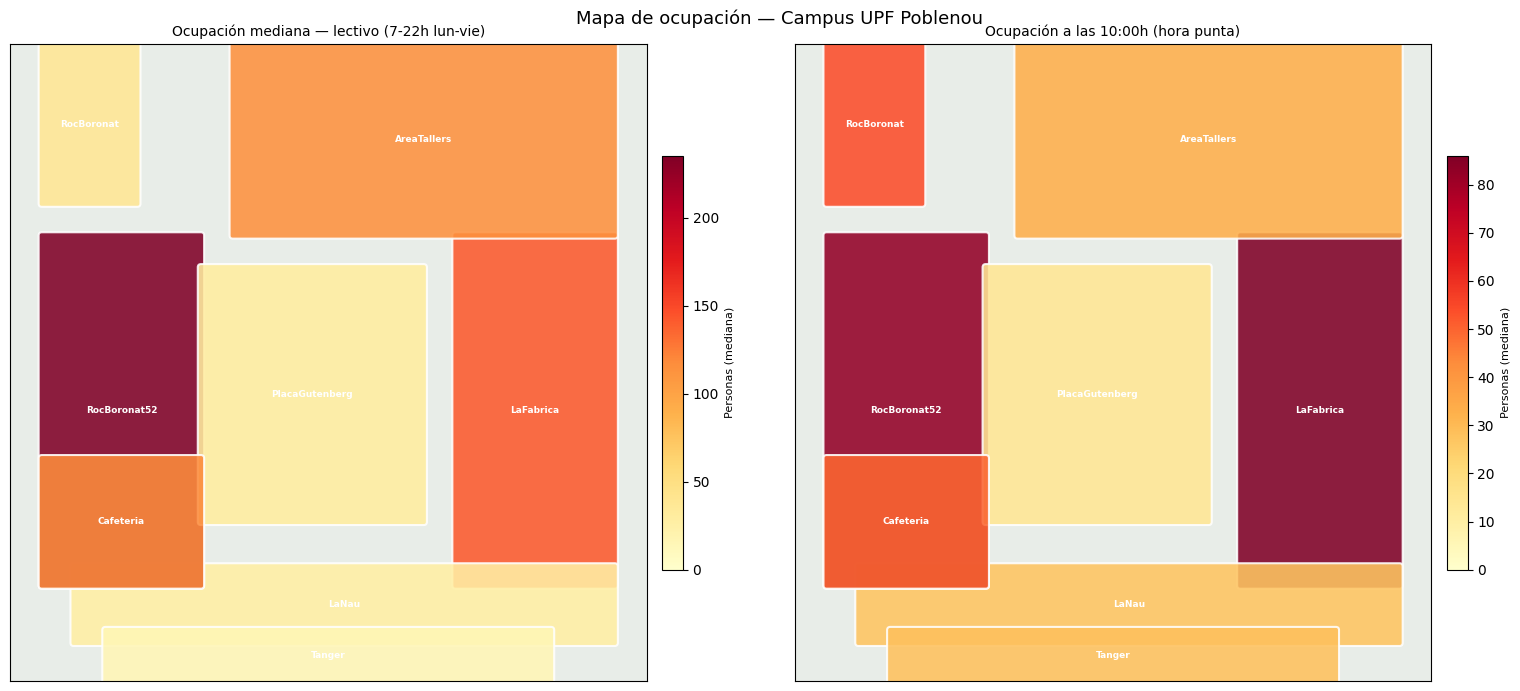

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 4 — Mapa campus choropleth (ocupación media vs hora punta)
# ─────────────────────────────────────────────────────────────────────────────
print('4/5 Mapa campus — ocupación...')

occ_media = (
    occ_zona[occ_zona['lectivo'] & occ_zona['hora'].between(HORA_INICIO, HORA_FIN)]
    .groupby('ZoneKey')['personas']
    .median()
    .to_dict()
)
occ_punta = (
    occ_zona[occ_zona['hora'] == 10]
    .groupby('ZoneKey')['personas']
    .median()
    .to_dict()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
dibujar_campus(axes[0], occ_media,
               f'Ocupación mediana — lectivo ({HORA_INICIO}-{HORA_FIN}h lun-vie)',
               'YlOrRd', label_cbar='Personas (mediana)')
dibujar_campus(axes[1], occ_punta,
               'Ocupación a las 10:00h (hora punta)',
               'YlOrRd', label_cbar='Personas (mediana)')
plt.suptitle('Mapa de ocupación — Campus UPF Poblenou', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'mapa_ocupacion_campus.png', dpi=150, bbox_inches='tight')
plt.show()

---
### G5 — KDE densidad espacial por perfil (requiere GT_X/GT_Y)

5/5 KDE espacial por perfil...


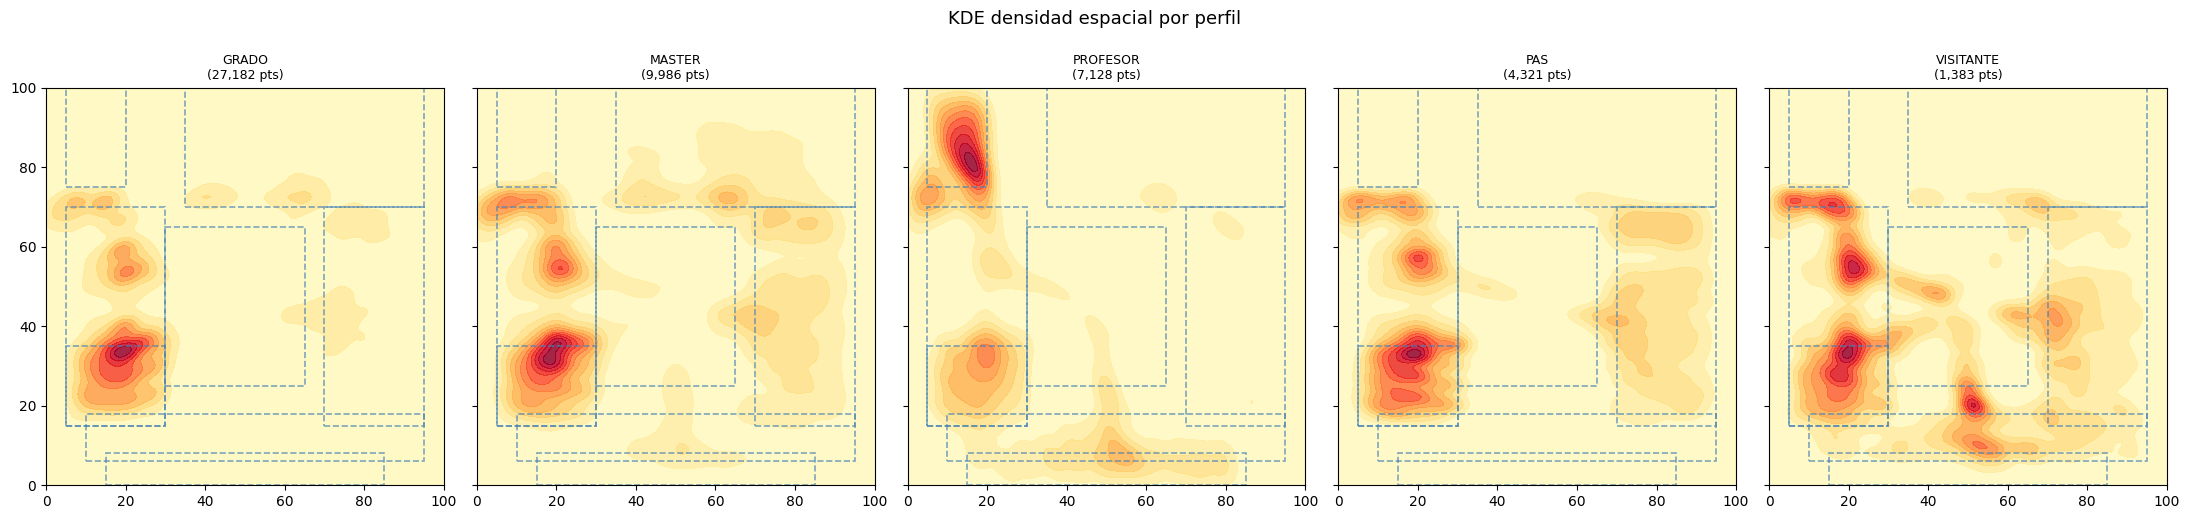

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 5 — KDE espacial por perfil
# ─────────────────────────────────────────────────────────────────────────────
print('5/5 KDE espacial por perfil...')

HAS_XY = 'GT_X' in df_raw.columns and 'GT_Y' in df_raw.columns

if HAS_XY:
    try:
        from scipy.stats import gaussian_kde

        sxy = (
            df_raw[df_raw['GT_TipoAgente'].isin(PERFILES)]
            [['GT_TipoAgente', 'GT_X', 'GT_Y']]
            .sample(min(50000, len(df_raw)), random_state=42)
            .dropna()
        )

        fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharex=True, sharey=True)
        for ax, p in zip(axes, PERFILES):
            sub = sxy[sxy['GT_TipoAgente'] == p]
            if len(sub) < 100:
                ax.set_title(f'{p}\n(sin datos)'); continue
            try:
                kde = gaussian_kde(np.vstack([sub['GT_X'], sub['GT_Y']]), bw_method=0.1)
                xi  = np.linspace(0, 100, 150)
                yi  = np.linspace(0, 100, 150)
                Xi, Yi = np.meshgrid(xi, yi)
                Zi  = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
                ax.contourf(Xi, Yi, Zi, levels=12, cmap='YlOrRd', alpha=0.85)
            except Exception:
                ax.hexbin(sub['GT_X'], sub['GT_Y'], gridsize=30, cmap='YlOrRd', mincnt=1)
            for info in EDIFICIOS.values():
                ax.add_patch(plt.Rectangle(
                    (info['x1'], info['y1']),
                    info['x2'] - info['x1'], info['y2'] - info['y1'],
                    fill=False, edgecolor='steelblue', lw=1.2, ls='--', alpha=0.7))
            ax.set_title(f'{p}\n({len(sub):,} pts)', fontsize=9)
            ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal')

        plt.suptitle('KDE densidad espacial por perfil', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.savefig(OUTPUTS / 'kde_espacial_perfiles.png', dpi=150, bbox_inches='tight')
        plt.show()
    except ImportError:
        print('  scipy no instalado — pip install scipy')
else:
    print('  GT_X/GT_Y no disponibles — saltando KDE')

---
## Bloque 9 — IMO (Índice de Mala Ocupación)

El IMO mide qué fracción del tiempo las instalaciones operan por debajo de su capacidad esperada.

```
IMO = 1 - (personas_reales / personas_esperadas)  ∈ [0, 1]
```
- `IMO ≈ 0`: zona al nivel esperado (eficiente)
- `IMO ≈ 1`: zona casi vacía (derroche energético)

La referencia (`personas_esperadas`) es el percentil 75 de ocupación para cada zona y hora lectiva.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 9a — Cálculo del IMO por zona y hora
# ─────────────────────────────────────────────────────────────────────────────
print('Calculando IMO por zona y hora...')

occ_lect = occ_zona[occ_zona['lectivo'] & occ_zona['hora'].between(HORA_INICIO, HORA_FIN)].copy()

# Baseline: percentil 75 de ocupación para cada (zona, hora)
baseline = (
    occ_lect
    .groupby(['ZoneKey', 'hora'])['personas']
    .quantile(0.75)
    .reset_index(name='esperadas')
)
baseline['esperadas'] = baseline['esperadas'].clip(lower=1)

imo = occ_lect.merge(baseline, on=['ZoneKey', 'hora'], how='left')
imo['imo'] = (1 - imo['personas'] / imo['esperadas']).clip(0, 1)

imo_media = imo.groupby('ZoneKey')['imo'].mean().to_dict()
pct_crit  = (
    imo[imo['imo'] > 0.5].groupby('ZoneKey').size() /
    imo.groupby('ZoneKey').size().clip(lower=1) * 100
).fillna(0).to_dict()

imo[['Hour', 'ZoneKey', 'personas', 'esperadas', 'imo']].to_parquet(
    OUT_DIR / 'imo_zona_hora.parquet', index=False)
print('✅ Guardado: imo_zona_hora.parquet')

Calculando IMO por zona y hora...
✅ Guardado: imo_zona_hora.parquet


Calculando el IMO General del Campus...

🌍 IMO GLOBAL DEL CAMPUS: 0.363
 ↳ Estado: SALUDABLE (Buena densidad de ocupación)


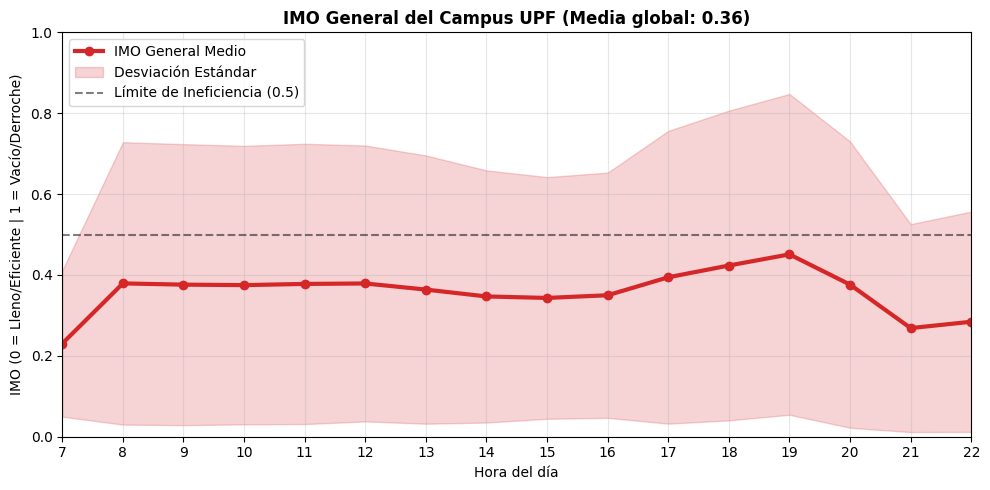

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 9c — IMO General del Campus (KPI global)
# ─────────────────────────────────────────────────────────────────────────────
print('Calculando el IMO General del Campus...')

# Agregar personas reales y esperadas de todas las zonas por hora
imo_campus = (
    imo
    .groupby(['Hour', 'hora'])
    .agg(personas_totales =('personas',  'sum'),
         esperadas_totales=('esperadas', 'sum'))
    .reset_index()
)
imo_campus['imo_general'] = (
    1 - imo_campus['personas_totales'] / imo_campus['esperadas_totales']
).clip(0, 1)

perfil_imo_general   = imo_campus.groupby('hora')['imo_general'].agg(['mean', 'std']).reset_index()
imo_global_absoluto  = imo_campus['imo_general'].mean()

print(f'\n🌍 IMO GLOBAL DEL CAMPUS: {imo_global_absoluto:.3f}')
if imo_global_absoluto > 0.4:
    print(' ↳ Estado: CRÍTICO (El campus opera casi a la mitad de su eficiencia térmica)')
else:
    print(' ↳ Estado: SALUDABLE (Buena densidad de ocupación)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(perfil_imo_general['hora'], perfil_imo_general['mean'],
        marker='o', lw=3, color='C3', label='IMO General Medio')
ax.fill_between(
    perfil_imo_general['hora'],
    (perfil_imo_general['mean'] - perfil_imo_general['std']).clip(0, 1),
    (perfil_imo_general['mean'] + perfil_imo_general['std']).clip(0, 1),
    color='C3', alpha=0.2, label='Desviación Estándar'
)
ax.axhline(0.5, color='black', ls='--', alpha=0.5, label='Límite de Ineficiencia (0.5)')
ax.set_ylim(0, 1)
ax.set_xlim(HORA_INICIO, HORA_FIN)
ax.set_xticks(range(HORA_INICIO, HORA_FIN + 1))
ax.set_title(f'IMO General del Campus UPF (Media global: {imo_global_absoluto:.2f})',
             fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('IMO (0 = Lleno/Eficiente | 1 = Vacío/Derroche)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'imo_general_campus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bloque 10 — Validaciones con Ground Truth

Cuatro validaciones independientes que miden la calidad del pipeline de deduplicación:

| Validación | Qué mide |
|------------|----------|
| **V1** | Exactitud de conteo de personas vs GT |
| **V2** | Precisión de localización por zona (requiere GT_X/Y) |
| **V3** | Bondad del modelo de propagación RSSI (requiere GT_Distance) |
| **V4** | Separabilidad de perfiles con K-Means sin etiquetas |

V1 — Validación: ocupación GT vs pipeline...


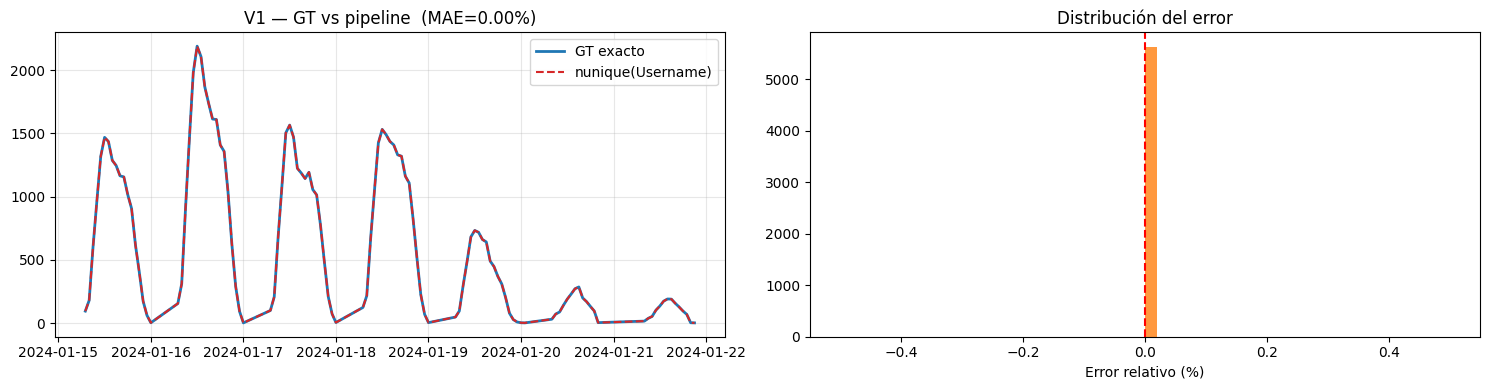

  Error relativo medio: 0.000%


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 10 — V1: Ocupación GT exacta vs pipeline
# ─────────────────────────────────────────────────────────────────────────────
print('V1 — Validación: ocupación GT vs pipeline...')

df_v1 = df_raw.copy()
df_v1['Hour'] = df_v1['Timestamp'].dt.ceil('1h')

occ_gt_h = (
    df_v1[df_v1['GT_TipoAgente'] != 'FIJO']
    .groupby('Hour')['Username']
    .nunique()
    .reset_index(name='gt')
)
occ_pipe = (
    ocupacion_horaria
    .rename(columns={'Timestamp': 'Hour', 'personas_total': 'pipe'})
    .assign(Hour=lambda d: pd.to_datetime(d['Hour']))
)

v1 = occ_gt_h.merge(occ_pipe, on='Hour', how='inner')
v1['err_pct'] = (v1['pipe'] - v1['gt']).abs() / v1['gt'].clip(lower=1) * 100

mw = (v1['Hour'] >= '2024-01-15') & (v1['Hour'] < '2024-01-22')
sv = v1[mw]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(sv['Hour'], sv['gt'],   lw=2,   label='GT exacto',              color='C0')
axes[0].plot(sv['Hour'], sv['pipe'], lw=1.5, label='nunique(Username)',       ls='--', color='C3')
axes[0].set_title(f'V1 — GT vs pipeline  (MAE={v1["err_pct"].mean():.2f}%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(v1['err_pct'].clip(0, 20), bins=50, color='C1', alpha=0.8)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Error relativo (%)')
axes[1].set_title('Distribución del error')

plt.tight_layout()
plt.savefig(OUTPUTS / 'val_v1_ocupacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Error relativo medio: {v1["err_pct"].mean():.3f}%')

V2 — Validación: localización WiFi (requiere GT_X/Y)...


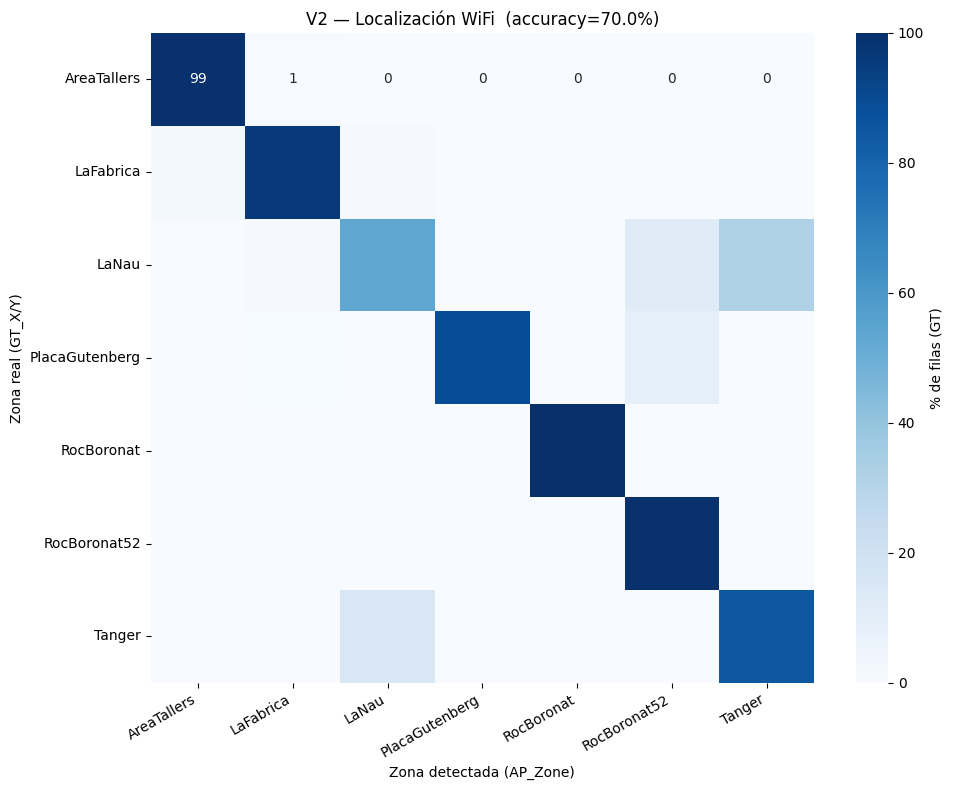

  Accuracy localización: 70.0%


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 10 — V2: Localización AP_Zone vs GT zona real
# ─────────────────────────────────────────────────────────────────────────────
print('V2 — Validación: localización WiFi (requiere GT_X/Y)...')

HAS_XY = 'GT_X' in df_raw.columns and 'GT_Y' in df_raw.columns

if HAS_XY:
    sloc = (
        df_raw[df_raw['GT_TipoAgente'].isin(PERFILES)]
        [['AP_Zone', 'GT_X', 'GT_Y', 'GT_TipoAgente']]
        .sample(min(200000, len(df_raw)), random_state=42)
        .dropna()
    )
    BOUNDS = {k: (v['x1'], v['x2'], v['y1'], v['y2']) for k, v in EDIFICIOS.items()}

    def zona_desde_xy(x, y):
        for z, (x1, x2, y1, y2) in BOUNDS.items():
            if x1 <= x <= x2 and y1 <= y <= y2:
                return z
        return 'Exterior'

    sloc['GT_Zone']  = sloc.apply(lambda r: zona_desde_xy(r['GT_X'], r['GT_Y']), axis=1)
    sloc['AP_ZoneK'] = sloc['AP_Zone'].apply(norm_zone)
    acc_loc = (sloc['GT_Zone'] == sloc['AP_ZoneK']).mean() * 100

    from sklearn.metrics import confusion_matrix as cm_fn
    zc  = sorted(set(sloc['GT_Zone'].unique()) & set(sloc['AP_ZoneK'].unique()))
    cm  = cm_fn(sloc['GT_Zone'], sloc['AP_ZoneK'], labels=zc)
    cmp = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1) * 100

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cmp, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=zc, yticklabels=zc,
                cbar_kws={'label': '% de filas (GT)'}, ax=ax)
    ax.set_title(f'V2 — Localización WiFi  (accuracy={acc_loc:.1f}%)')
    ax.set_xlabel('Zona detectada (AP_Zone)')
    ax.set_ylabel('Zona real (GT_X/Y)')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout()
    plt.savefig(OUTPUTS / 'val_v2_localizacion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Accuracy localización: {acc_loc:.1f}%')
else:
    print('  GT_X/GT_Y no disponibles — saltando V2')

V3 — Validación: modelo RSSI (requiere GT_Distance_m)...


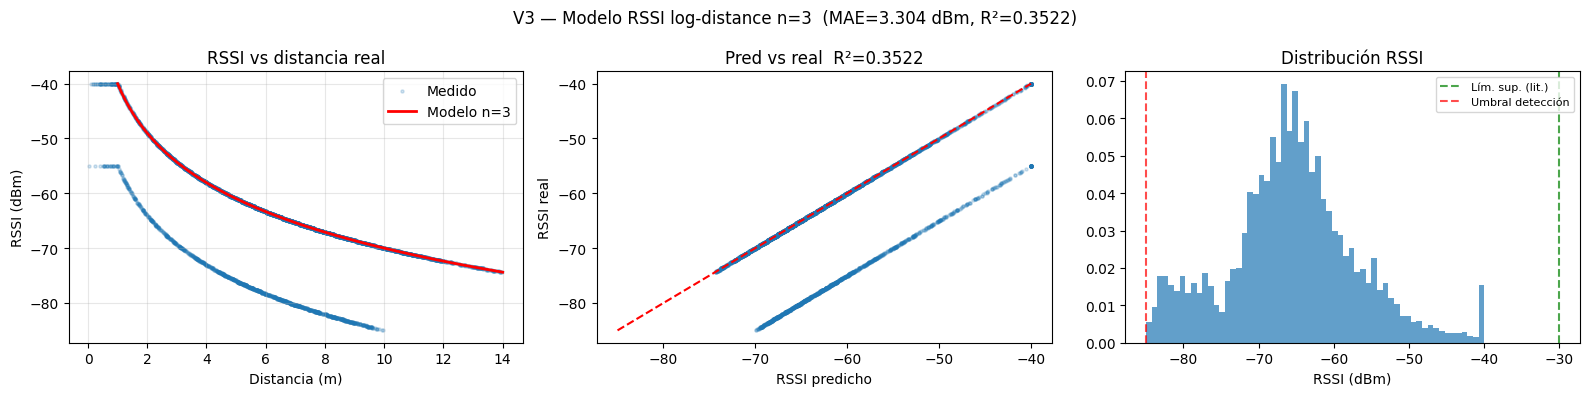

  MAE=3.304 dBm  |  R²=0.3522


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 10 — V3: Modelo RSSI log-distance path loss
# ─────────────────────────────────────────────────────────────────────────────
print('V3 — Validación: modelo RSSI (requiere GT_Distance_m)...')

HAS_DIST = 'GT_Distance_m' in df_raw.columns

if HAS_DIST:
    sr = (
        df_raw[df_raw['GT_TipoAgente'].isin(PERFILES)]
        [['RSSI_dBm', 'GT_Distance_m']]
        .sample(min(100000, len(df_raw)), random_state=42)
        .dropna()
    )
    sr = sr[sr['GT_Distance_m'] > 0].copy()
    sr['rssi_pred'] = -40 - 30 * np.log10(sr['GT_Distance_m'].clip(lower=1))

    from sklearn.metrics import r2_score, mean_absolute_error
    r2r  = r2_score(sr['RSSI_dBm'], sr['rssi_pred'])
    maer = mean_absolute_error(sr['RSSI_dBm'], sr['rssi_pred'])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ss = sr.sample(min(5000, len(sr)), random_state=42)

    axes[0].scatter(ss['GT_Distance_m'], ss['RSSI_dBm'], alpha=0.2, s=5, color='C0', label='Medido')
    dr = np.linspace(1, sr['GT_Distance_m'].max(), 200)
    axes[0].plot(dr, -40 - 30 * np.log10(dr), color='red', lw=2, label='Modelo n=3')
    axes[0].set_xlabel('Distancia (m)'); axes[0].set_ylabel('RSSI (dBm)')
    axes[0].set_title('RSSI vs distancia real'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].scatter(sr['rssi_pred'].sample(min(5000, len(sr)), random_state=42),
                    sr['RSSI_dBm'].sample(min(5000, len(sr)), random_state=42),
                    alpha=0.2, s=5)
    lim2 = [sr['RSSI_dBm'].min(), sr['RSSI_dBm'].max()]
    axes[1].plot(lim2, lim2, 'r--', lw=1.5)
    axes[1].set_xlabel('RSSI predicho'); axes[1].set_ylabel('RSSI real')
    axes[1].set_title(f'Pred vs real  R²={r2r:.4f}')

    axes[2].hist(sr['RSSI_dBm'], bins=60, density=True, alpha=0.7)
    axes[2].axvline(-30, color='green', ls='--', alpha=0.7, label='Lím. sup. (lit.)')
    axes[2].axvline(-85, color='red',   ls='--', alpha=0.7, label='Umbral detección')
    axes[2].set_xlabel('RSSI (dBm)'); axes[2].set_title('Distribución RSSI')
    axes[2].legend(fontsize=8)

    plt.suptitle(f'V3 — Modelo RSSI log-distance n=3  (MAE={maer:.3f} dBm, R²={r2r:.4f})',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'val_v3_rssi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  MAE={maer:.3f} dBm  |  R²={r2r:.4f}')
else:
    print('  GT_Distance_m no disponible — saltando V3')

V4 — Validación: clustering K-Means vs Ground Truth...


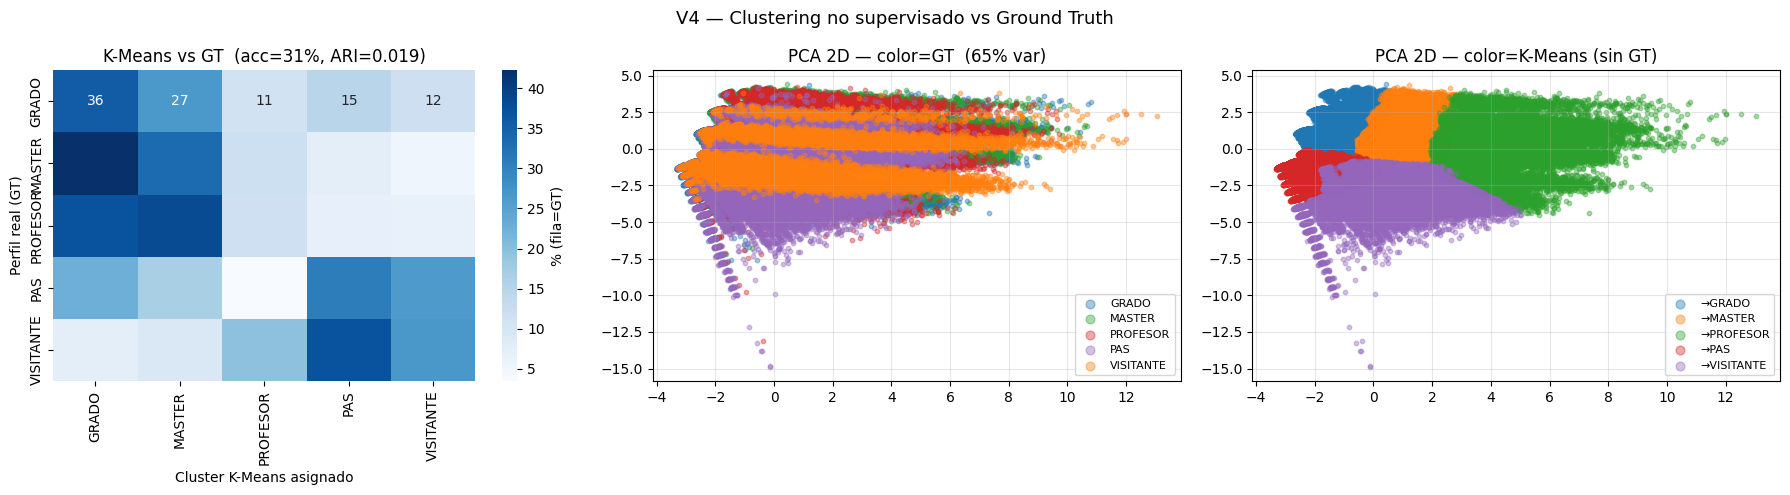

  Accuracy=31.5%  |  ARI=0.019  |  NMI=0.044


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 10 — V4: K-Means clustering vs GT_TipoAgente
# ─────────────────────────────────────────────────────────────────────────────
print('V4 — Validación: clustering K-Means vs Ground Truth...')

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                                  confusion_matrix as cm_fn2)
    from sklearn.decomposition import PCA
    from scipy.optimize import linear_sum_assignment

    gt_map = (
        df_raw[['Username', 'GT_TipoAgente']]
        .drop_duplicates('Username')
        .dropna()
        .query('GT_TipoAgente in @PERFILES')
    )

    FCOLS = [c for c in ['n_sesiones', 'n_aps_distintos', 'n_zonas_distintas',
                          'n_dispositivos', 'minutos_campus', 'dwell_por_sesion',
                          'ratio_movilidad', 'hora_centro', 'rssi_medio']
             if c in features.columns]

    user_agg = (
        features
        .merge(gt_map, on='Username', how='inner')
        .groupby(['Username', 'GT_TipoAgente'])[FCOLS]
        .median()
        .reset_index()
        .dropna()
    )

    X_c  = user_agg[FCOLS].values
    y_tr = user_agg['GT_TipoAgente'].values
    X_sc = StandardScaler().fit_transform(X_c)

    km   = KMeans(n_clusters=5, random_state=42, n_init=20)
    yp_r = km.fit_predict(X_sc)

    # Asignación óptima cluster → perfil (Hungarian algorithm)
    l2i  = {p: i for i, p in enumerate(PERFILES)}
    y_ti = np.array([l2i.get(l, 0) for l in y_tr])
    cm_c = cm_fn2(y_ti, yp_r)
    ri, ci = linear_sum_assignment(-cm_c)
    mapp = {col: PERFILES[row] for row, col in zip(ri, ci)}
    yp   = np.array([mapp.get(p, '?') for p in yp_r])

    acc = (y_tr == yp).mean() * 100
    ari = adjusted_rand_score(y_tr, yp)
    nmi = normalized_mutual_info_score(y_tr, yp)

    cmf   = cm_fn2(y_tr, yp, labels=PERFILES)
    cmpct = cmf.astype(float) / cmf.sum(axis=1, keepdims=True).clip(min=1) * 100

    pca = PCA(n_components=2, random_state=42)
    X2d = pca.fit_transform(X_sc)
    cp  = {'GRADO': 'C0', 'MASTER': 'C2', 'PROFESOR': 'C3', 'PAS': 'C4', 'VISITANTE': 'C1'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(cmpct, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=PERFILES, yticklabels=PERFILES,
                cbar_kws={'label': '% (fila=GT)'}, ax=axes[0])
    axes[0].set_title(f'K-Means vs GT  (acc={acc:.0f}%, ARI={ari:.3f})')
    axes[0].set_xlabel('Cluster K-Means asignado')
    axes[0].set_ylabel('Perfil real (GT)')

    for p in PERFILES:
        m = y_tr == p
        axes[1].scatter(X2d[m, 0], X2d[m, 1], alpha=0.4, s=10, label=p, color=cp.get(p, 'gray'))
    axes[1].set_title(f'PCA 2D — color=GT  ({pca.explained_variance_ratio_[:2].sum()*100:.0f}% var)')
    axes[1].legend(markerscale=2, fontsize=8); axes[1].grid(alpha=0.3)

    cmap_km = plt.get_cmap('tab10')
    for i, p in enumerate(PERFILES):
        m = yp == p
        axes[2].scatter(X2d[m, 0], X2d[m, 1], alpha=0.4, s=10,
                         label=f'→{p}', color=cmap_km(i))
    axes[2].set_title('PCA 2D — color=K-Means (sin GT)')
    axes[2].legend(markerscale=2, fontsize=8); axes[2].grid(alpha=0.3)

    plt.suptitle('V4 — Clustering no supervisado vs Ground Truth', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'val_v4_clustering.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Accuracy={acc:.1f}%  |  ARI={ari:.3f}  |  NMI={nmi:.3f}')

except Exception as e:
    print(f'  V4 falló: {e}')
    print('  Verifica que sklearn y scipy estén instalados: pip install scikit-learn scipy')